# Predict-Then-Optimise

In [1]:
import json
import time
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
from scipy.optimize import minimize_scalar
from sklearn.preprocessing import StandardScaler
import torch
from torch import nn

ROOT = Path.cwd().resolve()
if not (ROOT / "empirical" / "data" / "processed" / "macro_panel_quarterly.csv").exists() and (ROOT / "dfl_for_capital_allocation").is_dir():
    ROOT = ROOT / "dfl_for_capital_allocation"
while ROOT != ROOT.parent and not (ROOT / "empirical" / "data" / "processed" / "macro_panel_quarterly.csv").exists():
    ROOT = ROOT.parent
if not (ROOT / "empirical" / "data" / "processed" / "macro_panel_quarterly.csv").exists():
    raise FileNotFoundError("Could not locate the project root containing empirical/data/processed/macro_panel_quarterly.csv")

import sys
sys.path.insert(0, str(ROOT))
from minou_colours import MINOU_COLOURS

FIGURES_DIR = ROOT / "empirical" / "figures" / "02_pto"
RESULTS_DIR = ROOT / "empirical" / "results" / "pto"
METADATA_PATH = ROOT / "empirical" / "data" / "processed" / "empirical_panel_metadata.json"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
METADATA_PATH.parent.mkdir(parents=True, exist_ok=True)

## Configuration
Decision and Basel constants (`LGD`, `M`, `K1`, `LEVERAGE`, `Y_BAR`, `LAMBDA`, the PD floor)
are defined and written to `empirical_panel_metadata.json` once the panel is
loaded to be used in `03_black_box_empirical` and `04_dfl_empirical` to ensure all models use the same decision environment. 

In [2]:
# Data conventions
CHARGE_OFF_IS_PERCENT = True
HORIZON = 1
DATE_COL = "DATE"
TARGET_COL = "charge_off_rate"
INCLUDE_CURRENT_CQ = True

# Decision and Basel constants
LGD = 0.45
M = 2.5
K1 = 1.0
LEVERAGE = 10.0
Y_BAR = 0.0168
LAMBDA = 10.0
RHO_SCALE = 0.03

# Basel corporate PD floor (0.03%)
APPLY_PD_FLOOR = True
PD_FLOOR = 3e-4

PD_Q_CLIP_LOW = 1e-6
PD_Q_CLIP_HIGH = 0.99
PD_A_CLIP_LOW = 1e-6
PD_A_CLIP_HIGH = 0.99

# Allocation decisions are optimised continuously on [0, 1] with a bounded scalar solver
ALPHA_BOUNDS = (0.0, 1.0)
ALPHA_OPT_XATOL = 1e-10


# Evaluation splits: separate expanding-window experiments
SPLIT_NAME = "stress"
SPLIT_CFG = {"first_test_date": "2006-01-01"}

## Quarterly PD, Basel IRB, and allocation objective

In [3]:
# Shared code, imported from the simulation pipeline's package 
SIMULATION_ROOT = ROOT / "simulation"
sys.path.insert(0, str(SIMULATION_ROOT))
from common import decision as dec
from common import model_config as mcfg
from common import pto_model
from common.decision import DecisionConfig
from empirical.common import data as emp_data
from empirical.common import model_config as empirical_mcfg

DCFG = DecisionConfig(
    LGD=LGD, K1=K1, ell=LEVERAGE, Y_BAR=Y_BAR, lambda_shortfall=LAMBDA, M=M, RHO_SCALE=RHO_SCALE,
    APPLY_PD_FLOOR=APPLY_PD_FLOOR, PD_FLOOR=PD_FLOOR,
    PD_Q_CLIP_LOW=PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH=PD_Q_CLIP_HIGH,
    PD_A_CLIP_LOW=PD_A_CLIP_LOW, PD_A_CLIP_HIGH=PD_A_CLIP_HIGH,
    ALPHA_BOUNDS=ALPHA_BOUNDS, ALPHA_OPT_XATOL=ALPHA_OPT_XATOL,
)

MODEL_CFG = empirical_mcfg.make_model_config(mcfg.ModelConfig)
MLP_SEEDS = empirical_mcfg.ENSEMBLE_SEEDS

def clip_pd_q(pd_q):
    return dec.clip_pd_q(pd_q, DCFG)


def clip_pd_a(pd_a):
    return dec.clip_pd_a(pd_a, DCFG)


def quarterly_pd_to_annual(pd_q):
    return dec.quarterly_pd_to_annual(pd_q, DCFG)


def k_irb_from_annual_pd(pd_a, lgd=None, m=None, apply_floor=None):
    return dec.k_irb_from_annual_pd(pd_a, DCFG, lgd=lgd, m=m, apply_floor=apply_floor)


def decision_components(alpha, c_q, pd_a):
    k = dec.k_irb_from_annual_pd(pd_a, DCFG)
    return dec.decision_components(alpha, c_q, k, DCFG)


def optimise_alpha_continuous(c_q, pd_a):
    k = dec.k_irb_from_annual_pd(pd_a, DCFG)
    return dec.optimise_alpha_oracle(c_q, k, DCFG)

## Load and align data

In [5]:
macro_csv = ROOT / "empirical" / "data" / "processed" / "macro_panel_quarterly.csv"
df = emp_data.load_quarterly_pd_panel(
    macro_csv, dcfg=DCFG, date_col=DATE_COL, target_col=TARGET_COL, horizon=HORIZON,
    charge_off_is_percent=CHARGE_OFF_IS_PERCENT,
    include_current_cq=INCLUDE_CURRENT_CQ)
feature_cols = df.attrs["feature_cols"]

print(f"Observations after alignment and one-step target: {len(df)}")
print(f"Feature date range: {df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")
print(f"Target date range: {df['target_date'].min().date()} to {df['target_date'].max().date()}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
assert "c_q_lag1" in feature_cols
assert ("c_q" in feature_cols) == INCLUDE_CURRENT_CQ
assert not any(col.startswith("pd_q") or col.startswith("pd_a") for col in feature_cols)
print(f"Lag features included: c_q_lag1{' and current-quarter c_q' if INCLUDE_CURRENT_CQ else ''}; PD columns excluded.")
display(df.head())

# Write decision/Basel constants to metadata JSON for 03_bb and 04_dfl
empirical_metadata = emp_data.write_panel_metadata(
    METADATA_PATH, DCFG, feature_cols=feature_cols, n_observations=len(df),
    date_range=[str(df[DATE_COL].min().date()), str(df[DATE_COL].max().date())],
    charge_off_is_percent=CHARGE_OFF_IS_PERCENT,
    include_current_cq=INCLUDE_CURRENT_CQ, pd_clip_low=PD_Q_CLIP_LOW, pd_clip_high=PD_Q_CLIP_HIGH)
print(f"Saved metadata")

Observations after alignment and one-step target: 142
Feature date range: 1990-07-01 to 2025-10-01
Target date range: 1990-10-01 to 2026-01-01
Features (14): ['real_gdp_growth', 'unemployment_rate', 'industrial_production', 'real_disposable_personal_income', 'cpi', 'house_price_index', 'federal_funds_rate', 'treasury_10y_2y_spread', 'vix', 'corporate_bond_spread', 'senior_loan_officer_survey', 'excess_bond_premium', 'c_q', 'c_q_lag1']
Lag features included: c_q_lag1 and current-quarter c_q; PD columns excluded.


,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,...,c_q,pd_q,pd_a,c_q_lag1,target_date,c_annual_raw_next,c_q_realised,pd_q_realised,pd_a_realised,target_pd_q_next
0,1990-07-01,0.3,5.700000,0.386851,0.014248,1.712502,0.607283,8.160000,0.602540,25.195556,...,0.003200,0.007111,0.028142,0.003575,1990-10-01,1.30,0.003250,0.007222,0.028577,0.007222
1,1990-10-01,-3.6,6.133333,-1.560018,-0.804251,1.683668,-0.390403,7.743333,0.800161,26.113281,...,0.003250,0.007222,0.028577,0.003200,1991-01-01,1.48,0.003700,0.008222,0.032485,0.008222
2,1991-01-01,-1.9,6.600000,-1.932577,0.306683,0.744790,0.833014,6.426667,0.987167,22.515833,...,0.003700,0.008222,0.032485,0.003250,1991-04-01,1.86,0.004650,0.010333,0.040697,0.010333
3,1991-04-01,3.2,6.833333,0.526353,0.748178,0.591864,0.660265,5.863333,1.231406,17.147031,...,0.004650,0.010333,0.040697,0.003700,1991-07-01,1.97,0.004925,0.010944,0.043064,0.010944
4,1991-07-01,2.0,6.866667,1.390822,0.383417,0.759342,0.195457,5.643333,1.428906,16.634219,...,0.004925,0.010944,0.043064,0.004650,1991-10-01,1.83,0.004575,0.010167,0.040051,0.010167


Saved metadata


## Expanding-window evaluation

In [6]:
def build_result_row(base_row, pd_q_hat, model_name, split_name, pd_q_hat_std=float("nan")):
    pd_q_hat = float(clip_pd_q(pd_q_hat))
    c_q_hat = float(LGD * pd_q_hat)
    pd_a_hat = float(quarterly_pd_to_annual(pd_q_hat))
    c_q_realised = float(base_row["c_q_realised"])
    pd_q_realised = float(base_row["pd_q_realised"])
    pd_a_realised = float(base_row["pd_a_realised"])

    alpha_hat, _ = optimise_alpha_continuous(c_q=c_q_hat, pd_a=pd_a_hat)
    alpha_oracle, utility_oracle = optimise_alpha_continuous(c_q=c_q_realised, pd_a=pd_a_realised)
    realised_components = decision_components(alpha_hat, c_q=c_q_realised, pd_a=pd_a_realised)
    oracle_components = decision_components(alpha_oracle, c_q=c_q_realised, pd_a=pd_a_realised)
    predicted_components = decision_components(alpha_hat, c_q=c_q_hat, pd_a=pd_a_hat)
    regret = utility_oracle - realised_components["utility"]

    return {"split": split_name, "model": model_name, "date": pd.to_datetime(base_row["target_date"]),
            "feature_date": pd.to_datetime(base_row[DATE_COL]), "c_annual_raw": float(base_row["c_annual_raw_next"]),
            "c_q_lag1": float(base_row["c_q_lag1"]),
            "c_q_realised": c_q_realised, "pd_q_realised": pd_q_realised, "pd_a_realised": pd_a_realised,
            "pd_q_hat": pd_q_hat, "pd_q_hat_std": float(pd_q_hat_std), "pd_a_hat": pd_a_hat, "c_q_hat": c_q_hat,
            "k_irb_realised": float(k_irb_from_annual_pd(pd_a_realised)), "k_irb_hat": float(k_irb_from_annual_pd(pd_a_hat)),
            "alpha_oracle": alpha_oracle, "alpha_hat": alpha_hat, "utility_oracle": utility_oracle,
            "utility": realised_components["utility"], "regret": regret,
            "shortfall_oracle": oracle_components["shortfall"],
            "shortfall_realised_at_hat": realised_components["shortfall"],
            "shortfall_predicted_at_hat": predicted_components["shortfall"]}


def resolve_first_test_idx(df, split_cfg):
    if "initial_train_frac" in split_cfg:
        first_test_idx = int(np.floor(len(df) * float(split_cfg["initial_train_frac"])))
    elif "first_test_date" in split_cfg:
        mask = (df["target_date"] >= pd.Timestamp(split_cfg["first_test_date"])).to_numpy()
        if not mask.any():
            raise ValueError("first_test_date is after the last available target date.")
        first_test_idx = int(np.flatnonzero(mask)[0])
    else:
        raise ValueError("Split config needs 'initial_train_frac' or 'first_test_date'.")
    if first_test_idx < 30 or len(df) - first_test_idx < 5:
        raise ValueError(f"Split leaves too little data: first_test_idx={first_test_idx} of {len(df)}.")
    return first_test_idx


def run_expanding_window_pd_irb(df, feature_cols, split_name, split_cfg, model_cfg=MODEL_CFG,
                                return_history=True, stability_reference_X=None):
    first_test_idx = resolve_first_test_idx(df, split_cfg)
    total = len(df) - first_test_idx
    print(f"[{split_name}] first test target: {pd.Timestamp(df['target_date'].iloc[first_test_idx]).date()}, "
          f"{total} windows, {first_test_idx} initial training obs")
    records, histories = [], []
    stability_linear_rows, stability_mlp_rows = [], []
    t0 = time.time()
    for test_idx in range(first_test_idx, len(df)):
        train_df = df.iloc[:test_idx]
        test_row = df.iloc[test_idx]
        scaler = StandardScaler()
        x_train = scaler.fit_transform(train_df[feature_cols].to_numpy(dtype=float))
        y_train = train_df["target_pd_q_next"].to_numpy(dtype=float)
        x_test = scaler.transform(test_row[feature_cols].to_numpy(dtype=float).reshape(1, -1))

        linear_model, linear_hist = pto_model.train_pd_model(
            x_train, y_train, "linear", model_cfg, DCFG, return_history=True)
        records.append(build_result_row(
            test_row, float(pto_model.predict_pd_q(linear_model, x_test, DCFG)[0]), "linear", split_name))

        if stability_reference_X is not None:
            _x_ref_lin = scaler.transform(stability_reference_X)
            _ref_pred_lin = pto_model.predict_pd_q(linear_model, _x_ref_lin, DCFG)
            _ref_alpha_lin = []
            for _p in _ref_pred_lin:
                _p_clip = float(clip_pd_q(_p))
                _a_ref, _ = optimise_alpha_continuous(
                    c_q=float(LGD * _p_clip), pd_a=float(quarterly_pd_to_annual(_p_clip)))
                _ref_alpha_lin.append(_a_ref)
            _row_lin = {"split": split_name, "refit_step": test_idx - first_test_idx,
                        "test_date": pd.to_datetime(test_row["target_date"]),
                        "train_end_date": pd.to_datetime(train_df[DATE_COL].iloc[-1]),
                        "n_train": len(train_df)}
            for _i, _p in enumerate(_ref_pred_lin):
                _row_lin[f"ref{_i}_pd_q_hat_mean"] = float(_p)
            for _i, _a in enumerate(_ref_alpha_lin):
                _row_lin[f"ref{_i}_alpha_hat_mean"] = float(_a)
            stability_linear_rows.append(_row_lin)

        mlp_models, mlp_hist = pto_model.train_mlp_ensemble(
            x_train, y_train, model_cfg, DCFG, seeds=MLP_SEEDS, return_history=True)
        mlp_mean, mlp_std = pto_model.predict_pd_q_ensemble(mlp_models, x_test, DCFG)
        records.append(build_result_row(test_row, float(mlp_mean[0]), "mlp", split_name, pd_q_hat_std=float(mlp_std[0])))
       
        if stability_reference_X is not None:
            _x_ref = scaler.transform(stability_reference_X)
            _member_pd = np.stack([pto_model.predict_pd_q(m, _x_ref, DCFG) for m in mlp_models], axis=0)
            _ref_mean, _ref_std = _member_pd.mean(axis=0), _member_pd.std(axis=0)
            _ref_alpha_mlp = []
            for _m in _ref_mean:
                _m_clip = float(clip_pd_q(_m))
                _a_ref, _ = optimise_alpha_continuous(
                    c_q=float(LGD * _m_clip), pd_a=float(quarterly_pd_to_annual(_m_clip)))
                _ref_alpha_mlp.append(_a_ref)
            _row = {"split": split_name, "refit_step": test_idx - first_test_idx,
                    "test_date": pd.to_datetime(test_row["target_date"]),
                    "train_end_date": pd.to_datetime(train_df[DATE_COL].iloc[-1]), "n_train": len(train_df)}
            for _i, (_m, _s) in enumerate(zip(_ref_mean, _ref_std)):
                _row[f"ref{_i}_pd_q_hat_mean"] = float(_m)
                _row[f"ref{_i}_pd_q_hat_std"] = float(_s)
                for _seed, _pred in zip(MLP_SEEDS, _member_pd[:, _i]):
                    _row[f"ref{_i}_pd_q_hat_seed{int(_seed)}"] = float(_pred)
                    _m_clip = float(clip_pd_q(_pred))
                    _a_seed, _ = optimise_alpha_continuous(c_q=float(LGD * _m_clip), pd_a=float(quarterly_pd_to_annual(_m_clip)))
                    _row[f"ref{_i}_alpha_hat_seed{int(_seed)}"] = float(_a_seed)
            for _i, _a in enumerate(_ref_alpha_mlp):
                _row[f"ref{_i}_alpha_hat_mean"] = float(_a)
            stability_mlp_rows.append(_row)

        # Persistence baseline: current-quarter implied PD carried forward
        records.append(build_result_row(test_row, float(clip_pd_q(test_row["c_q"] / LGD)), "persistence", split_name))

        if return_history:
            for hist in (linear_hist, mlp_hist):
                if hist is not None:
                    hist = hist.copy()
                    hist["split"] = split_name
                    hist["test_date"] = pd.to_datetime(test_row["target_date"])
                    hist["train_end_date"] = pd.to_datetime(train_df[DATE_COL].iloc[-1])
                    histories.append(hist)

        done = test_idx - first_test_idx + 1
        if done % 5 == 0 or test_idx == len(df) - 1:
            print(f"[{split_name}] completed {done}/{total} windows ({time.time() - t0:.0f}s elapsed)")
    pred_long = pd.DataFrame(records).sort_values(["date", "model"]).reset_index(drop=True)
    history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
    stability_linear = pd.DataFrame(stability_linear_rows)
    stability_mlp = pd.DataFrame(stability_mlp_rows)
    return pred_long, history, stability_linear, stability_mlp

STABILITY_N_REFERENCE_POINTS = 24
STABILITY_REFERENCE_SEED = 7
df["date"] = df[DATE_COL] 

STABILITY_REF_X, STABILITY_REF_DATES = pto_model.select_stability_reference_points(
    df, feature_cols, STABILITY_N_REFERENCE_POINTS, STABILITY_REFERENCE_SEED)

split_frames, split_histories, split_stability_linear, split_stability_mlp = [], [], [], []
split_name, split_cfg = SPLIT_NAME, SPLIT_CFG
pl, th, sl, sm = run_expanding_window_pd_irb(
    df, feature_cols, split_name, split_cfg, stability_reference_X=STABILITY_REF_X)
split_frames.append(pl)
split_histories.append(th)
split_stability_linear.append(sl)
split_stability_mlp.append(sm)
pred_long = pd.concat(split_frames, ignore_index=True)
training_history = pd.concat([h for h in split_histories if not h.empty], ignore_index=True)
stability_linear = pd.concat([s for s in split_stability_linear if not s.empty], ignore_index=True)
stability_mlp = pd.concat([s for s in split_stability_mlp if not s.empty], ignore_index=True)
display(pred_long.head())

[stress] first test target: 2006-01-01, 81 windows, 61 initial training obs
[stress] completed 5/81 windows (41s elapsed)
[stress] completed 10/81 windows (68s elapsed)
[stress] completed 15/81 windows (86s elapsed)
[stress] completed 20/81 windows (111s elapsed)
[stress] completed 25/81 windows (135s elapsed)
[stress] completed 30/81 windows (165s elapsed)
[stress] completed 35/81 windows (201s elapsed)
[stress] completed 40/81 windows (245s elapsed)
[stress] completed 45/81 windows (338s elapsed)
[stress] completed 50/81 windows (402s elapsed)
[stress] completed 55/81 windows (448s elapsed)
[stress] completed 60/81 windows (477s elapsed)
[stress] completed 65/81 windows (497s elapsed)
[stress] completed 70/81 windows (516s elapsed)
[stress] completed 75/81 windows (538s elapsed)
[stress] completed 80/81 windows (561s elapsed)
[stress] completed 81/81 windows (566s elapsed)


,split,model,date,feature_date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,pd_q_hat,...,k_irb_realised,k_irb_hat,alpha_oracle,alpha_hat,utility_oracle,utility,regret,shortfall_oracle,shortfall_realised_at_hat,shortfall_predicted_at_hat
0,stress,linear,2006-01-01,2005-10-01,0.21,0.000525,0.000525,0.001167,0.004659,0.001839,...,0.053913,0.065635,0.726543,0.668170,1.118245,1.108745,0.009500,0.0,0.0,0.0
1,stress,mlp,2006-01-01,2005-10-01,0.21,0.000525,0.000525,0.001167,0.004659,0.001826,...,0.053913,0.065453,0.726543,0.669010,1.118245,1.108881,0.009363,0.0,0.0,0.0
2,stress,persistence,2006-01-01,2005-10-01,0.21,0.000525,0.000525,0.001167,0.004659,0.001722,...,0.053913,0.063911,0.726543,0.676197,1.118245,1.110051,0.008194,0.0,0.0,0.0
3,stress,linear,2006-04-01,2006-01-01,0.27,0.000775,0.000675,0.001500,0.005987,0.001734,...,0.060307,0.064092,0.693570,0.675345,1.111838,1.108899,0.002939,0.0,0.0,0.0
4,stress,mlp,2006-04-01,2006-01-01,0.27,0.000775,0.000675,0.001500,0.005987,0.001529,...,0.060307,0.060806,0.693570,0.691113,1.111838,1.111442,0.000396,0.0,0.0,0.0


## Result collection

In [7]:
base_cols = ["date", "c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised", "pd_a_realised",
             "k_irb_realised", "alpha_oracle", "utility_oracle"]
metric_cols = ["pd_q_hat", "pd_a_hat", "c_q_hat", "k_irb_hat", "alpha_hat", "utility", "regret"]
MODEL_ORDER = ["linear", "mlp", "persistence"]

def make_wide_results(pred_long, split_name):
    sub = pred_long[pred_long["split"] == split_name]
    wide = sub.pivot(index="date", columns="model", values=metric_cols).sort_index()
    wide.columns = [f"{metric}_{model}" for metric, model in wide.columns]
    wide = wide.reset_index()
    base = sub[sub["model"] == "linear"][base_cols].copy()
    out = base.merge(wide, on="date", how="left")
    ordered = base_cols + [f"{m}_{mod}" for m in metric_cols for mod in MODEL_ORDER]
    return out[ordered].sort_values("date").reset_index(drop=True)

results_by_split = {}
for split_name in [SPLIT_NAME]:
    res = make_wide_results(pred_long, split_name)
    results_by_split[split_name] = res
    output_csv = RESULTS_DIR / "pto_quarterly_pd_irb_predictions.csv"
    res.to_csv(output_csv, index=False)
    print(f"[{split_name}] saved {len(res)} rows to {output_csv.relative_to(ROOT)}")
    lin_sub = stability_linear[stability_linear["split"] == split_name]
    mlp_sub = stability_mlp[stability_mlp["split"] == split_name]
    lin_csv = RESULTS_DIR / "pto_stability_linear_reference_outputs.csv"
    mlp_csv = RESULTS_DIR / "pto_stability_mlp_reference_outputs.csv"
    lin_sub.to_csv(lin_csv, index=False)
    mlp_sub.to_csv(mlp_csv, index=False)
    print(f"[{split_name}] saved {len(lin_sub)} linear reference-output rows to {lin_csv.relative_to(ROOT)}")
    print(f"[{split_name}] saved {len(mlp_sub)} MLP reference-output rows to {mlp_csv.relative_to(ROOT)}")
display(results_by_split["stress"].head())

[stress] saved 81 rows to empirical/results/pto/pto_quarterly_pd_irb_predictions.csv
[stress] saved 81 linear reference-output rows to empirical/results/pto/pto_stability_linear_reference_outputs.csv
[stress] saved 81 MLP reference-output rows to empirical/results/pto/pto_stability_mlp_reference_outputs.csv


,date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,k_irb_realised,alpha_oracle,utility_oracle,pd_q_hat_linear,...,k_irb_hat_persistence,alpha_hat_linear,alpha_hat_mlp,alpha_hat_persistence,utility_linear,utility_mlp,utility_persistence,regret_linear,regret_mlp,regret_persistence
0,2006-01-01,0.21,0.000525,0.000525,0.001167,0.004659,0.053913,0.726543,1.118245,0.001839,...,0.063911,0.668170,0.669010,0.676197,1.108745,1.108881,1.110051,0.009500,0.009363,0.008194
1,2006-04-01,0.27,0.000775,0.000675,0.001500,0.005987,0.060307,0.693570,1.111838,0.001734,...,0.053913,0.675345,0.691113,0.726543,1.108899,1.111442,0.641744,0.002939,0.000396,0.470094
2,2006-07-01,0.30,0.000525,0.000750,0.001667,0.006650,0.063051,0.680266,1.109183,0.001558,...,0.060307,0.688724,0.701293,0.693570,0.986206,0.803457,0.915742,0.122976,0.305725,0.193440
3,2006-10-01,0.34,0.000675,0.000850,0.001889,0.007534,0.066343,0.664926,1.106056,0.001689,...,0.063051,0.678592,0.695897,0.680266,0.902704,0.645210,0.877802,0.203351,0.460845,0.228254
4,2007-01-01,0.37,0.000750,0.000925,0.002056,0.008197,0.068577,0.654869,1.103960,0.002152,...,0.066343,0.649505,0.654215,0.664926,1.103109,1.103857,0.951990,0.000852,0.000104,0.151970


## Diagnostics and sanity checks

In [11]:
def describe_columns(frame, cols):
    return frame[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

print(f"Charge-off input is percent-scaled; simple x4 annualisation inverted; "
      f"PD floor applied: {APPLY_PD_FLOOR} ({PD_FLOOR:.2%}); MLP seeds: {MLP_SEEDS}")
print(f"Loss: Vasicek NLL; RHO_SCALE: {RHO_SCALE}")

assert np.allclose(pred_long["pd_q_realised"], clip_pd_q(pred_long["c_q_realised"] / LGD))
for col in ["pd_q_realised", "pd_q_hat", "pd_a_realised", "pd_a_hat"]:
    vals = pred_long[col].to_numpy()
    assert np.isfinite(vals).all() and (vals > 0.0).all() and (vals < 1.0).all(), col
for col in ["k_irb_realised", "k_irb_hat"]:
    vals = pred_long[col].to_numpy()
    assert np.isfinite(vals).all() and (vals >= 0.0).all(), col

assert np.allclose(pred_long["pd_a_realised"], quarterly_pd_to_annual(pred_long["pd_q_realised"]), atol=1e-12)
assert np.allclose(pred_long["pd_a_hat"], quarterly_pd_to_annual(pred_long["pd_q_hat"]), atol=1e-12)
assert np.allclose(pred_long["k_irb_hat"], k_irb_from_annual_pd(pred_long["pd_a_hat"].to_numpy()), atol=1e-12)
print("IRB check passed: k_irb_from_annual_pd is called on annualised PD columns only.")

min_regret = pred_long["regret"].min()
if min_regret < -1e-10:
    raise AssertionError(f"Meaningfully negative regret found: {min_regret}")
print(f"Minimum regret across splits and models: {min_regret:.3e}")

summary_cols = (["c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised"]
                + [f"pd_q_hat_{m}" for m in MODEL_ORDER]
                + ["pd_a_realised"] + [f"pd_a_hat_{m}" for m in MODEL_ORDER]
                + ["k_irb_realised"] + [f"k_irb_hat_{m}" for m in MODEL_ORDER]
                + ["alpha_oracle"] + [f"alpha_hat_{m}" for m in MODEL_ORDER]
                + [f"regret_{m}" for m in MODEL_ORDER])
for split_name, res in [(SPLIT_NAME, results_by_split[SPLIT_NAME])]:
    print(f"=== {split_name} split summary ===")
    display(describe_columns(res, summary_cols))

shortfall_summary = pred_long.groupby(["split", "model"])[["shortfall_realised_at_hat", "shortfall_predicted_at_hat"]].agg(
    ["mean", "max", lambda s: float((s > 1e-12).mean())])
shortfall_summary = shortfall_summary.rename(columns={"<lambda_0>": "bind_share"})
print(f"Decision constants: LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}")
display(shortfall_summary)

mlp_std = pred_long[pred_long["model"] == "mlp"].groupby("split")["pd_q_hat_std"].describe()
print("Cross-seed std of MLP ensemble predictions (per split):")
display(mlp_std)

Charge-off input is percent-scaled; simple x4 annualisation inverted; PD floor applied: True (0.03%); MLP seeds: (42, 43, 44, 45, 46)
Loss: Vasicek NLL; RHO_SCALE: 0.03
IRB check passed: k_irb_from_annual_pd is called on annualised PD columns only.
Minimum regret across splits and models: 0.000e+00
=== stress split summary ===


,count,mean,std,min,5%,25%,50%,75%,95%,max
c_annual_raw,81.0,0.578025,0.540653,0.120000,0.160000,0.270000,0.410000,0.570000,1.940000,2.570000
c_q_lag1,81.0,0.001426,0.001357,0.000300,0.000400,0.000675,0.000925,0.001400,0.004850,0.006425
c_q_realised,81.0,0.001445,0.001352,0.000300,0.000400,0.000675,0.001025,0.001425,0.004850,0.006425
pd_q_realised,81.0,0.003211,0.003004,0.000667,0.000889,0.001500,0.002278,0.003167,0.010778,0.014278
pd_q_hat_linear,81.0,0.005160,0.008282,0.001320,0.001559,0.001922,0.002459,0.003174,0.023193,0.058105
pd_q_hat_mlp,81.0,0.003815,0.002929,0.001131,0.001354,0.002134,0.002836,0.004097,0.010170,0.014607
pd_q_hat_persistence,81.0,0.003192,0.003008,0.000667,0.000889,0.001500,0.002167,0.003111,0.010778,0.014278
pd_a_realised,81.0,0.012730,0.011780,0.002664,0.003551,0.005987,0.009080,0.012607,0.042419,0.055900
pd_a_hat_linear,81.0,0.020088,0.030997,0.005270,0.006223,0.007664,0.009801,0.012634,0.089592,0.212938
pd_a_hat_mlp,81.0,0.015121,0.011484,0.004516,0.005404,0.008509,0.011295,0.016289,0.040064,0.057160


Decision constants: LEVERAGE=10.0, Y_BAR=0.0168, LAMBDA=10.0


shortfall_realised_at_hat                       \
                                        mean       max bind_share   
split  model                                                        
stress linear                       0.007825  0.100532   0.259259   
       mlp                          0.011404  0.151488   0.296296   
       persistence                  0.014488  0.079900   0.518519   

                   shortfall_predicted_at_hat                           
                                         mean           max bind_share  
split  model                                                            
stress linear                    2.288695e-12  1.853843e-10   0.012346  
       mlp                       4.922099e-12  1.734097e-10   0.037037  
       persistence               0.000000e+00  0.000000e+00   0.000000

Cross-seed std of MLP ensemble predictions (per split):


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
stress,81.0,0.000718,0.000825,0.000033,0.000279,0.000451,0.000815,0.004992


## Plots

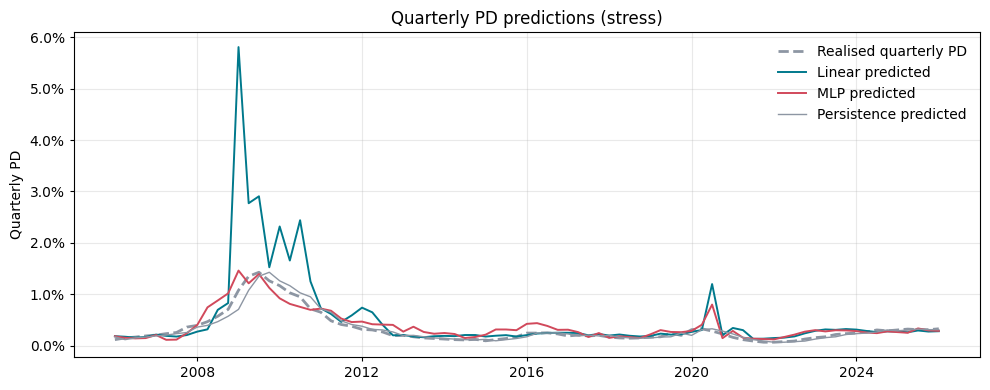

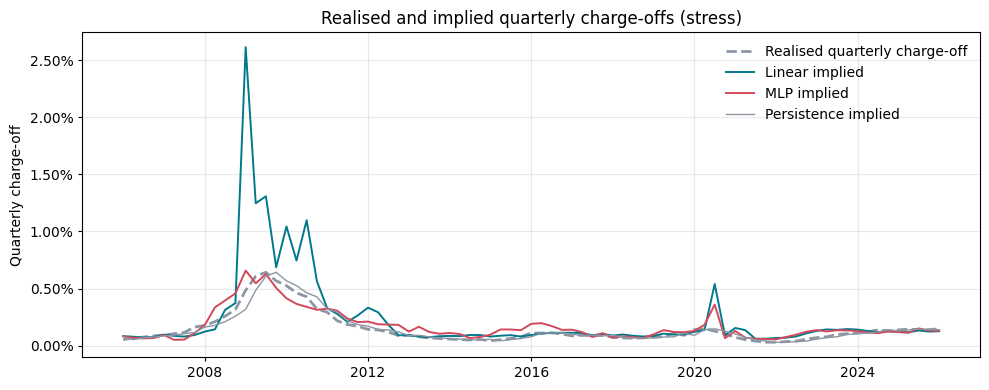

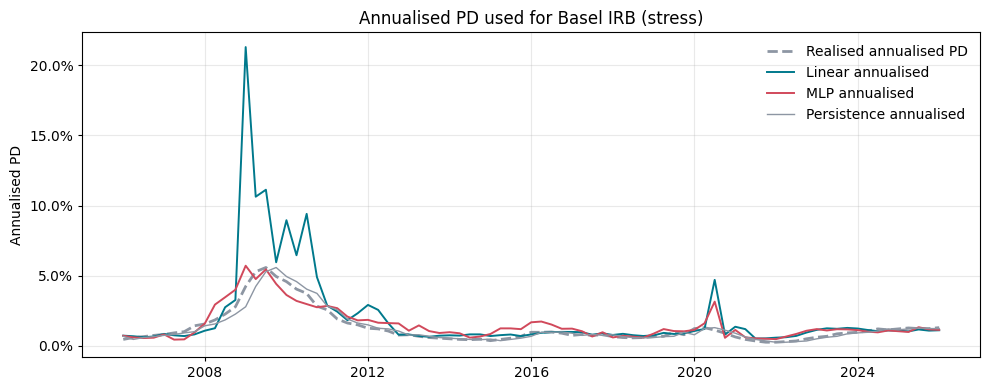

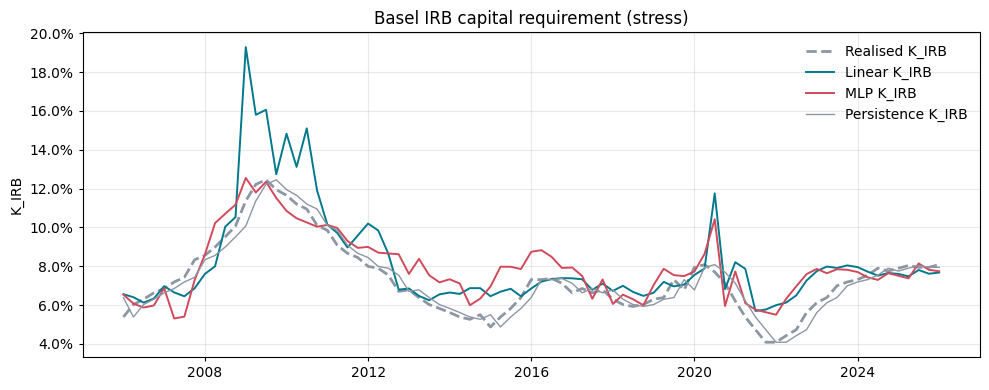

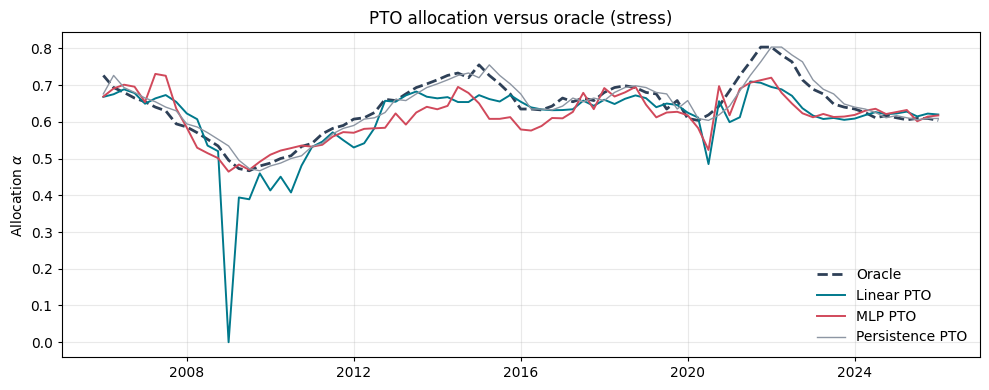

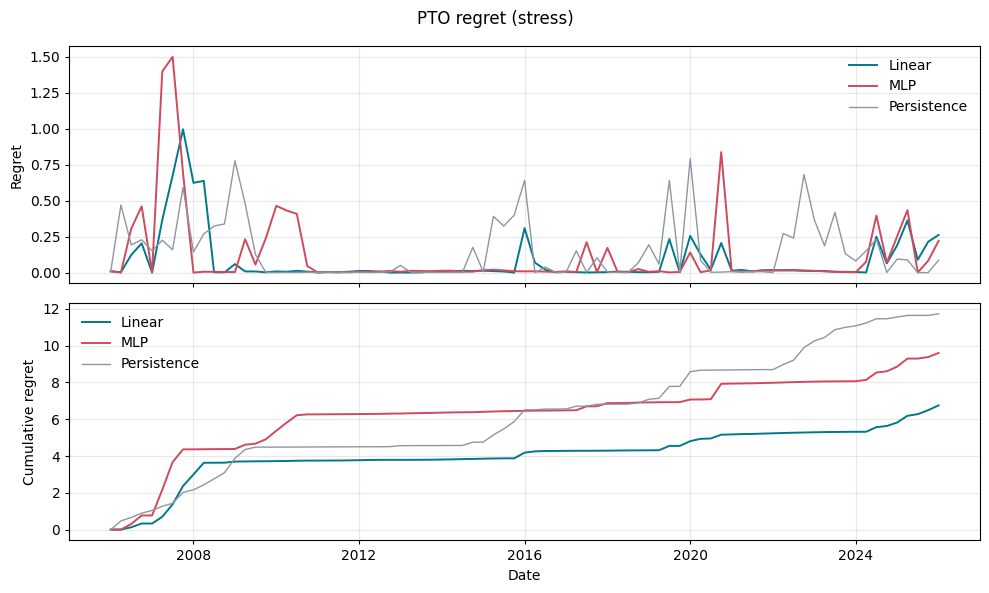

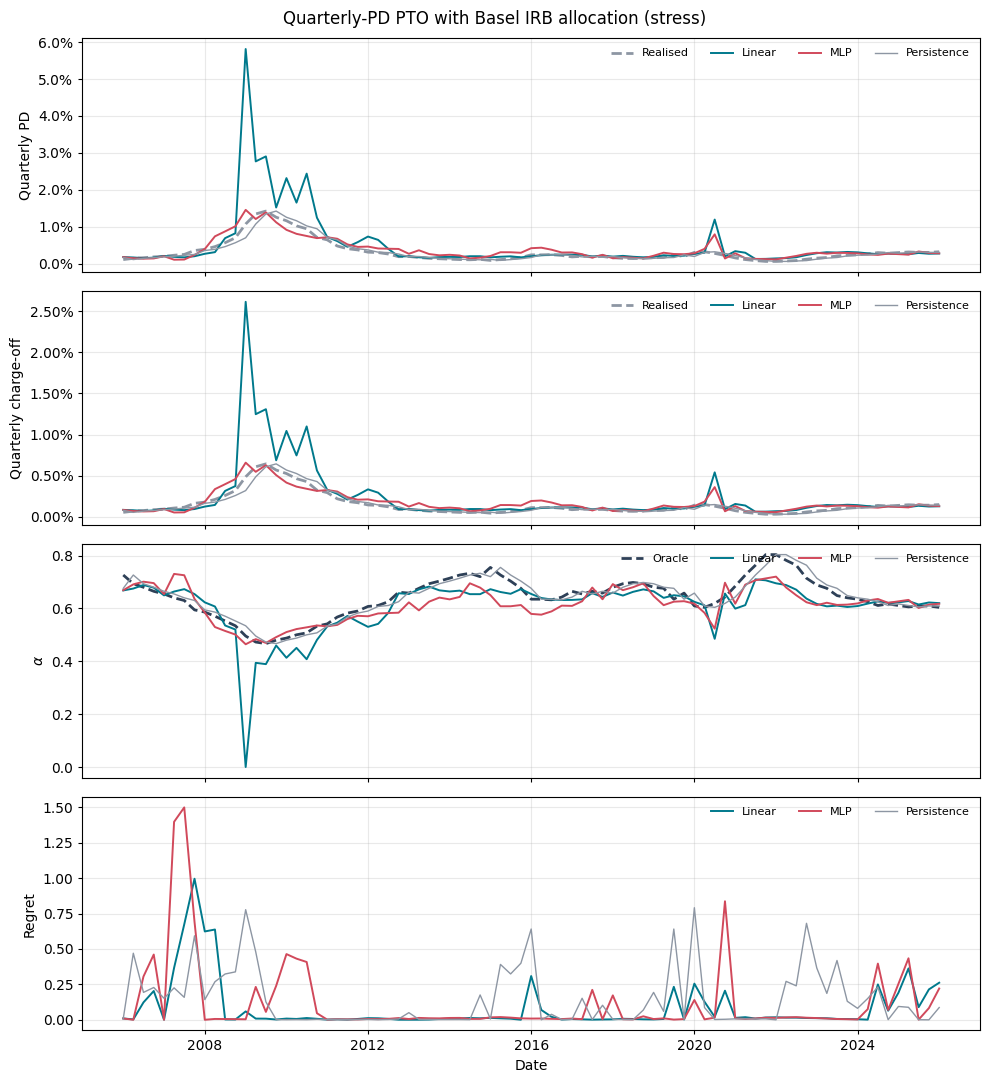

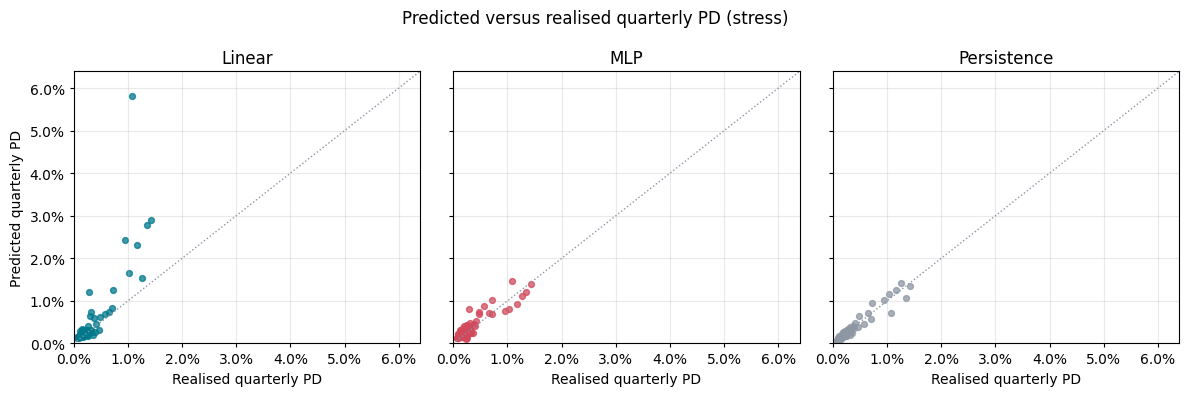

In [13]:
plt.rcdefaults()
plt.rcParams.update({"font.size": 10, "axes.linewidth": 0.8, "xtick.direction": "out", "ytick.direction": "out",
                     "xtick.major.size": 3, "ytick.major.size": 3, "font.sans-serif": ["DejaVu Sans"]})
MODEL_COLORS = {"linear": MINOU_COLOURS["teal"], "mlp": MINOU_COLOURS["coral"], "persistence": MINOU_COLOURS["grey"]}
MODEL_LW = {"linear": 1.4, "mlp": 1.4, "persistence": 1.0}
MODEL_LABELS = {"linear": "Linear", "mlp": "MLP", "persistence": "Persistence"}
ORACLE_COLOR = MINOU_COLOURS["navy"]
REAL_COLOR = MINOU_COLOURS["grey"]

def format_date_axis(ax, year_step=2):
    ax.xaxis.set_major_locator(mdates.YearLocator(year_step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.28)


def _model_lines(ax, plot_df, col_prefix, suffix=""):
    for m in MODEL_ORDER:
        ax.plot(plot_df["date"], plot_df[f"{col_prefix}_{m}"], color=MODEL_COLORS[m],
                lw=MODEL_LW[m], label=f"{MODEL_LABELS[m]}{suffix}")


def plot_split(res, split_name):
    fig_dir = FIGURES_DIR
    fig_dir.mkdir(parents=True, exist_ok=True)
    plot_df = res.sort_values("date").copy()
    year_step = 2 if len(plot_df) <= 60 else 4

    # 1. Quarterly PD predictions
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["pd_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised quarterly PD")
    _model_lines(ax, plot_df, "pd_q_hat", " predicted")
    ax.set_ylabel("Quarterly PD"); ax.set_title(f"Quarterly PD predictions ({split_name})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "quarterly_pd_predictions.png", dpi=200, bbox_inches="tight"); plt.show()

    # 2. Quarterly charge-off predictions
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["c_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised quarterly charge-off")
    _model_lines(ax, plot_df, "c_q_hat", " implied")
    ax.set_ylabel("Quarterly charge-off"); ax.set_title(f"Realised and implied quarterly charge-offs ({split_name})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "quarterly_chargeoff_predictions.png", dpi=200, bbox_inches="tight"); plt.show()

    # 3. Annualised PD for IRB
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["pd_a_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised annualised PD")
    _model_lines(ax, plot_df, "pd_a_hat", " annualised")
    ax.set_ylabel("Annualised PD"); ax.set_title(f"Annualised PD used for Basel IRB ({split_name})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "annualised_pd_irb.png", dpi=200, bbox_inches="tight"); plt.show()

    # 4. IRB capital requirement
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["k_irb_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised K_IRB")
    _model_lines(ax, plot_df, "k_irb_hat", " K_IRB")
    ax.set_ylabel("K_IRB"); ax.set_title(f"Basel IRB capital requirement ({split_name})")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "irb_capital_requirement.png", dpi=200, bbox_inches="tight"); plt.show()

    # 5. Allocation comparison
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
    _model_lines(ax, plot_df, "alpha_hat", " PTO")
    ax.set_ylabel(r"Allocation $\alpha$"); ax.set_title(f"PTO allocation versus oracle ({split_name})")
    format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
    plt.savefig(fig_dir / "allocation_comparison.png", dpi=200, bbox_inches="tight"); plt.show()

    # 6. Regret and cumulative regret
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    for m in MODEL_ORDER:
        axes[0].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
        axes[1].plot(plot_df["date"], plot_df[f"regret_{m}"].cumsum(), color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[0].set_ylabel("Regret"); axes[0].legend(frameon=False)
    axes[1].set_ylabel("Cumulative regret"); axes[1].set_xlabel("Date"); axes[1].legend(frameon=False)
    for ax in axes:
        format_date_axis(ax, year_step)
    fig.suptitle(f"PTO regret ({split_name})"); plt.tight_layout()
    plt.savefig(fig_dir / "regret.png", dpi=200, bbox_inches="tight"); plt.show()

    # 7. Compact 4-panel thesis figure
    fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
    fig.subplots_adjust(hspace=0.08)
    axes[0].plot(plot_df["date"], plot_df["pd_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised")
    _model_lines(axes[0], plot_df, "pd_q_hat")
    axes[0].set_ylabel("Quarterly PD"); axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1].plot(plot_df["date"], plot_df["c_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised")
    _model_lines(axes[1], plot_df, "c_q_hat")
    axes[1].set_ylabel("Quarterly charge-off"); axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[2].plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
    _model_lines(axes[2], plot_df, "alpha_hat")
    axes[2].set_ylabel(r"$\alpha$")
    for m in MODEL_ORDER:
        axes[3].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[3].set_ylabel("Regret"); axes[3].set_xlabel("Date")
    for ax in axes:
        format_date_axis(ax, year_step); ax.legend(fontsize=8, frameon=False, loc="upper right", ncol=4)
    fig.suptitle(f"Quarterly-PD PTO with Basel IRB allocation ({split_name})", fontsize=12)
    plt.tight_layout(); plt.savefig(fig_dir / "pto_pd_irb_compact_panel.png", dpi=220, bbox_inches="tight"); plt.show()

    # 8. Predicted vs realised scatter
    fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(4 * len(MODEL_ORDER), 4), sharex=True, sharey=True)
    lims = [0.0, max(plot_df["pd_q_realised"].max(), *(plot_df[f"pd_q_hat_{m}"].max() for m in MODEL_ORDER)) * 1.1]
    for ax, m in zip(np.atleast_1d(axes), MODEL_ORDER):
        ax.scatter(plot_df["pd_q_realised"], plot_df[f"pd_q_hat_{m}"], s=18, color=MODEL_COLORS[m], alpha=0.75)
        ax.plot(lims, lims, color=MINOU_COLOURS["grey"], lw=1, ls=":")
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_title(MODEL_LABELS[m]); ax.set_xlabel("Realised quarterly PD")
        ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        ax.grid(True, alpha=0.28)
    np.atleast_1d(axes)[0].set_ylabel("Predicted quarterly PD")
    fig.suptitle(f"Predicted versus realised quarterly PD ({split_name})")
    plt.tight_layout(); plt.savefig(fig_dir / "pred_vs_realised_scatter.png", dpi=200, bbox_inches="tight"); plt.show()


for split_name, res in [(SPLIT_NAME, results_by_split[SPLIT_NAME])]:
    plot_split(res, split_name)

## Learning curves

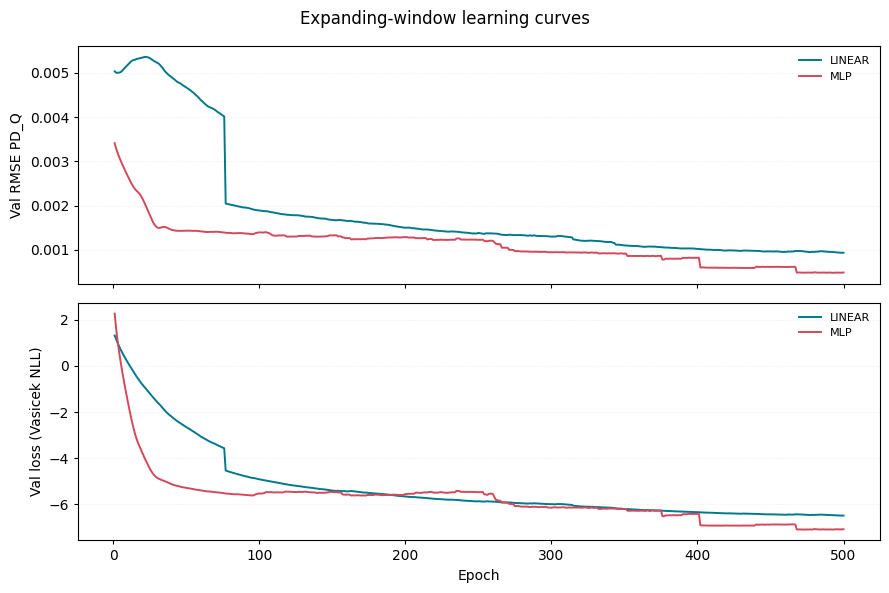

In [14]:
if not training_history.empty:
    for split_name, split_hist in training_history.groupby("split"):
        mean_history = split_hist.groupby(["model", "epoch"], as_index=False).agg(
            mean_val_rmse_pd_q=("val_rmse_pd_q", "mean"), mean_val_loss=("val_loss", "mean"))
        fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
        for model_name, group in mean_history.groupby("model"):
            group = group.sort_values("epoch"); color = MODEL_COLORS.get(model_name, "grey")
            axes[0].plot(group["epoch"], group["mean_val_rmse_pd_q"], color=color, lw=1.4, label=model_name.upper())
            axes[1].plot(group["epoch"], group["mean_val_loss"], color=color, lw=1.4, label=model_name.upper())
        axes[0].set_ylabel("Val RMSE PD_Q")
        axes[1].set_ylabel("Val loss (Vasicek NLL)"); axes[1].set_xlabel("Epoch")
        for ax in axes:
            ax.grid(True, axis="y", lw=0.5, alpha=0.3, linestyle=":"); ax.legend(fontsize=8, frameon=False, loc="upper right")
        fig.suptitle(f"Expanding-window learning curves"); plt.tight_layout()
        fig_dir = FIGURES_DIR
        fig_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(fig_dir / "learning_curves.png", dpi=200, bbox_inches="tight"); plt.show()